In [28]:
#Cargar libreria y el dataset
import numpy as np
datos = np.load('pisos_vendidos.npy')
datos

array([[    68,  83420],
       [    87,  98000],
       [    93,  95000],
       [    82,  75000],
       [   103, 118900],
       [   143, 152000],
       [    59,  54000],
       [    50,  45000],
       [    78,  71000],
       [    67,  63000],
       [    92, 120000],
       [    55,  49000],
       [   121, 139000]])

In [29]:
X = datos[0]
y = datos[1]

In [30]:
X = X.reshape(-1,1)
y = y.reshape(-1,1)

In [31]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_escalado = scaler.fit_transform(X)
y_escalado = scaler.fit_transform(y)

In [32]:
from keras.models import Sequential
modelo = Sequential()

from keras.layers import Dense
modelo.add(Dense(2, activation="selu", input_shape=(1,)))
modelo.add(Dense(1, activation=None))

modelo.summary()

c:\Users\David\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7 (28.00 B)

 Trainable params: 7 (28.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Configuramos el modelo con el compile
modelo.compile(
    loss = "mse",
    optimizer = "adam",
    metrics = ["mse"]
)

In [34]:
h = modelo.fit(
    X, 
    y, 
    epochs=500,
    batch_size=4,
    #validation_data=(X,y),
    verbose=False
)

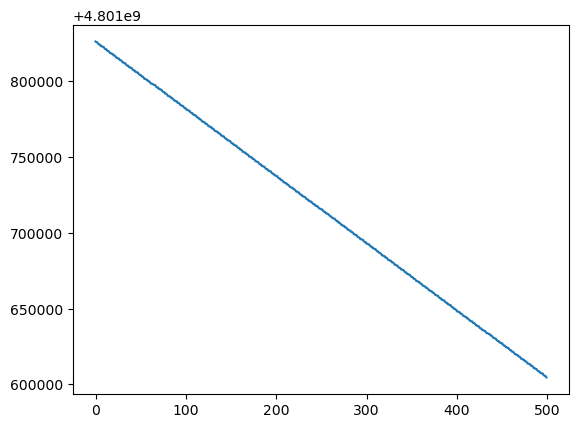

In [37]:
import matplotlib.pyplot as plt
plt.plot(h.history["loss"])